# House Classification 2.0

## Problem Statement
The objective is to predict whether a property belongs to the **expensive segment** (`Expensive = 1`) using the Kaggle House Prices dataset.

This version starts from the official Kaggle `train.csv`, creates the classification target from `SalePrice`, and keeps the Kaggle `test.csv` separate because it has no true `SalePrice` labels.

### Decision perspective (cost of errors)
False negatives are especially costly: an expensive property predicted as non-expensive may be under-prioritised. For that reason, model selection focuses on **F1-score, recall for the expensive class, PR-AUC, and false negatives**, not accuracy alone.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec 
from matplotlib.patches import Patch
from scipy import stats
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import pointbiserialr
from pathlib import Path

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

TARGET_COL = "Expensive"
KAGGLE_DIR = Path("house-prices-advanced-regression-techniques")
TRAIN_PATH = KAGGLE_DIR / "train.csv"
TEST_PATH = KAGGLE_DIR / "test.csv"
EXPENSIVE_QUANTILE = 0.85

assert TRAIN_PATH.exists(), f"Kaggle training file not found: {TRAIN_PATH}"
assert TEST_PATH.exists(), f"Kaggle test file not found: {TEST_PATH}"

raw_train = pd.read_csv(TRAIN_PATH)
kaggle_test = pd.read_csv(TEST_PATH)

assert "SalePrice" in raw_train.columns, "Kaggle train.csv must contain SalePrice."
assert "SalePrice" not in kaggle_test.columns, "Kaggle test.csv should not contain the real target."

EXPENSIVE_THRESHOLD = raw_train["SalePrice"].quantile(EXPENSIVE_QUANTILE)
sale_price = raw_train["SalePrice"].copy()

df = raw_train.copy()
df[TARGET_COL] = (df["SalePrice"] >= EXPENSIVE_THRESHOLD).astype(int)
df = df.drop(columns=["SalePrice"])

assert TARGET_COL in df.columns
assert "SalePrice" not in df.columns, "Leakage risk: SalePrice must not be used as a feature."

data = df
print("Loaded Kaggle train from:", TRAIN_PATH)
print("Kaggle train shape before target conversion:", raw_train.shape)
print("Modelling data shape after replacing SalePrice with Expensive:", df.shape)
print("Kaggle test shape kept for later prediction only:", kaggle_test.shape)
print(f"Created {TARGET_COL}=1 for houses with SalePrice >= {EXPENSIVE_THRESHOLD:,.0f} (top {1-EXPENSIVE_QUANTILE:.0%} segment).")
print("SalePrice was dropped from model features to avoid leakage.")
display(df.head(10))


Loaded Kaggle train from: house-prices-advanced-regression-techniques/train.csv
Kaggle train shape before target conversion: (1460, 81)
Modelling data shape after replacing SalePrice with Expensive: (1460, 81)
Kaggle test shape kept for later prediction only: (1459, 80)
Created Expensive=1 for houses with SalePrice >= 250,000 (top 15% segment).
SalePrice was dropped from model features to avoid leakage.


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,Expensive
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,0
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,0
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,0
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,0
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,1
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1.5Fin,5,5,1993,1995,Gable,CompShg,VinylSd,VinylSd,None,0.0,TA,TA,Wood,Gd,TA,No,GLQ,732,Unf,0,64,796,GasA,Ex,Y,SBrkr,796,566,0,1362,1,0,1,1,1,1,TA,5,Typ,0,NaN,Attchd,1993.0,Unf,2,480,TA,TA,Y,40,30,0,320,0,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,0
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Somerst,Norm,Norm,1Fam,1Story,8,5,2004,2005,Gable,CompShg,VinylSd,VinylSd,Stone,186.0,Gd,TA,PConc,Ex,TA,Av,GLQ,1369,Unf,0,317,1686,GasA,Ex,Y,SBrkr,1694,0,0,1694,1,0,2,0,3,1,Gd,7,Typ,1,Gd,Attchd,2004.0,RFn,2,636,TA,TA,Y,255,57,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,1
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NWAmes,PosN,Norm,1Fam,2Story,7,6,1973,1973,Gable,CompShg,HdBoard,HdBoard,Stone,240.0,TA,TA,CBlock,Gd,TA,Mn,ALQ,859,BLQ,32,216,1107,GasA,Ex,Y,SBrkr,1107,983,0,2090,1,0,2,1,3,1,TA,7,Typ,2,TA,Attchd,1973.0,RFn,2,484,TA,TA,Y,235,204,228,0,0,0,NaN,NaN,Shed,350,11,2009,WD,Normal,0
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,OldTown,Artery,Norm,1Fam,1.5Fin,7,5,1931,1950,Gable,CompShg,BrkFace,Wd Shng,None,0.0,TA,TA,BrkTil,TA,TA,No,Unf,0,Unf,0,952,952,GasA,Gd,Y,FuseF,1022,752,0,1774,0,0,2,0,2,2,TA,8,Min1,2,TA,Detchd,1931.0,Unf,2,468,Fa,TA,Y,90,0,205,0,0,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,0
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,BrkSide,Artery,Artery,2fmCon,1.5Unf,5,6,1939,1950,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,BrkTil,TA,TA,No,GLQ,851,Unf,0,140,991,GasA,Ex,Y,SBrkr,1077,0,0,1077,1,0,1,0,2,2,TA,5,T

---

# 1. Data Understanding & Feature Classification

Before building any machine learning model, it is essential to understand:

- What kind of data we have  
- What each variable represents  
- The context of the dataset  

This dataset contains property information from **Ames, Iowa (USA)**.

Understanding the geographic and structural context is important because it helps interpret variables such as *Neighborhood*, *Zoning*, and *Construction Quality* correctly.
Also it helps make right research if needed.

---

1. Therefore, the first step is grouping features by data type:

In [2]:
# Numerical
numerical_continuous = [
    "LotFrontage","LotArea","TotalBsmtSF","1stFlrSF","2ndFlrSF","GrLivArea",
    "GarageArea","WoodDeckSF","OpenPorchSF","EnclosedPorch","ScreenPorch",
    "PoolArea","MasVnrArea","BsmtFinSF1","BsmtFinSF2","BsmtUnfSF","MiscVal"
]

numerical_discrete = [
    "BedroomAbvGr","KitchenAbvGr","FullBath","HalfBath",
    "BsmtFullBath","BsmtHalfBath","TotRmsAbvGrd",
    "Fireplaces","GarageCars","MoSold","YrSold"
]

numerical_time = [
    "YearBuilt","YearRemodAdd","GarageYrBlt"
]

# Categorical
ordinal_features = [
    "OverallQual","OverallCond","ExterQual","ExterCond",
    "BsmtQual","BsmtCond","KitchenQual","FireplaceQu",
    "GarageQual","GarageCond","HeatingQC","PoolQC",
    "BsmtExposure","BsmtFinType1","BsmtFinType2",
    "LandSlope","LotShape","PavedDrive","GarageFinish"
]

nominal_features = [
    "Neighborhood","MSZoning","Condition1","Condition2",
    "Street","Alley","LandContour","LotConfig","Utilities",
    "CentralAir","Electrical","GarageType",
    "SaleType","SaleCondition","BldgType","HouseStyle",
    "RoofStyle","RoofMatl","Exterior1st","Exterior2nd",
    "MasVnrType","Foundation","Heating","Functional",
    "Fence","MiscFeature"
]


numerical_features = numerical_continuous + numerical_discrete + numerical_time
categorical_features = ordinal_features + nominal_features

Later we can do it automatically on preprocessing stage

---

2. Groop predictors in lists that represents effect on target feture from Size & Area as the most dominant predictors to Sale info.

In [3]:
# 1 Size & Area
size_features = ["LotFrontage","LotArea","TotalBsmtSF","1stFlrSF","2ndFlrSF",
                 "GrLivArea","GarageArea","WoodDeckSF","OpenPorchSF",
                 "EnclosedPorch","ScreenPorch","PoolArea","MasVnrArea"]

# 2 Rooms & Layout
room_features = ["BedroomAbvGr","KitchenAbvGr","FullBath","HalfBath",
                 "BsmtFullBath","BsmtHalfBath","TotRmsAbvGrd","Fireplaces"]

# 3 Construction & Age
construction_features = ["YearBuilt","YearRemodAdd","GarageYrBlt","MSSubClass"]

# 4 Quality (Ordinal)
quality_features = ["OverallQual","OverallCond","ExterQual","ExterCond",
                    "BsmtQual","BsmtCond","KitchenQual","FireplaceQu",
                    "GarageQual","GarageCond","HeatingQC","PoolQC"]

# 5 Location & Zoning
location_features = ["Neighborhood","MSZoning","Condition1","Condition2",
                     "Street","Alley","LotShape","LandContour",
                     "LandSlope","LotConfig"]

# 6 Utilities
utility_features = ["Utilities","CentralAir","Electrical","PavedDrive"]

# 7 Garage
garage_features = ["GarageType","GarageFinish","GarageCars"]

# 8 Basement
basement_features = ["BsmtExposure","BsmtFinType1","BsmtFinSF1",
                     "BsmtFinType2","BsmtFinSF2","BsmtUnfSF"]

# 9 Sale
sale_features = ["MoSold","YrSold","SaleType","SaleCondition"]

---

# 2. Data Preparation

#### The next step is data cleaning and transformation.

At this stage, we improve data quality and transform variables into more meaningful representations.

Depending on the feature type and business meaning, we may:

- Replace values
- Drop unnecessary variables
- Transform variables into more informative forms
- Create new engineered features

#### Feature Engineering Examples

Instead of using raw variables, we can create more meaningful features:

- **PropertyAge**  
  PropertyAge = CurrentYear − YearBuilt  
  Example: 2026 − 1985 = 41  

- **TotalBathrooms**  
  TotalBathrooms = FullBath + 0.5 × HalfBath + BsmtFullBath + 0.5 × BsmtHalfBath  
  

These transformations help reduce dimensionality and improve interpretability.

---

1. Discover feature type

In [4]:
category_var = df.select_dtypes(include = 'object')
num_var = df.select_dtypes(exclude = 'object')

print("Number of categorical features are: ", category_var.shape[1])
print("Number of numerical features are: ", num_var.shape[1])

Number of categorical features are:  43
Number of numerical features are:  38


2. Check for NaN values and they persentage

In [5]:
missing_categorical = pd.DataFrame({
    "Missing Values": df.isna().sum(),
    "Missing Values %": df.isna().mean() * 100
})

missing_categorical = missing_categorical[missing_categorical["Missing Values"] > 0].sort_values(
    by="Missing Values %", ascending=False
)
missing_categorical

,Missing Values,Missing Values %
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945
GarageQual,81,5.547945


3. Heawy 0 persentage contains

In [6]:
zero_check = df.select_dtypes(include="number")

missing_numerical = pd.DataFrame({
    "Zero Values": zero_check.eq(0).sum(),
    "Zero Values %": zero_check.eq(0).mean() * 100
})

missing_numerical = missing_numerical[missing_numerical["Zero Values"] > 0].sort_values(
    by="Zero Values %", ascending=False
)
missing_numerical

,Zero Values,Zero Values %
PoolArea,1453,99.520548
3SsnPorch,1436,98.356164
LowQualFinSF,1434,98.219178
MiscVal,1408,96.438356
BsmtHalfBath,1378,94.383562
ScreenPorch,1344,92.054795
BsmtFinSF2,1293,88.561644
EnclosedPorch,1252,85.753425
Expensive,1235,84.589041
HalfBath,913,62.534247


Lets visualise our missing values

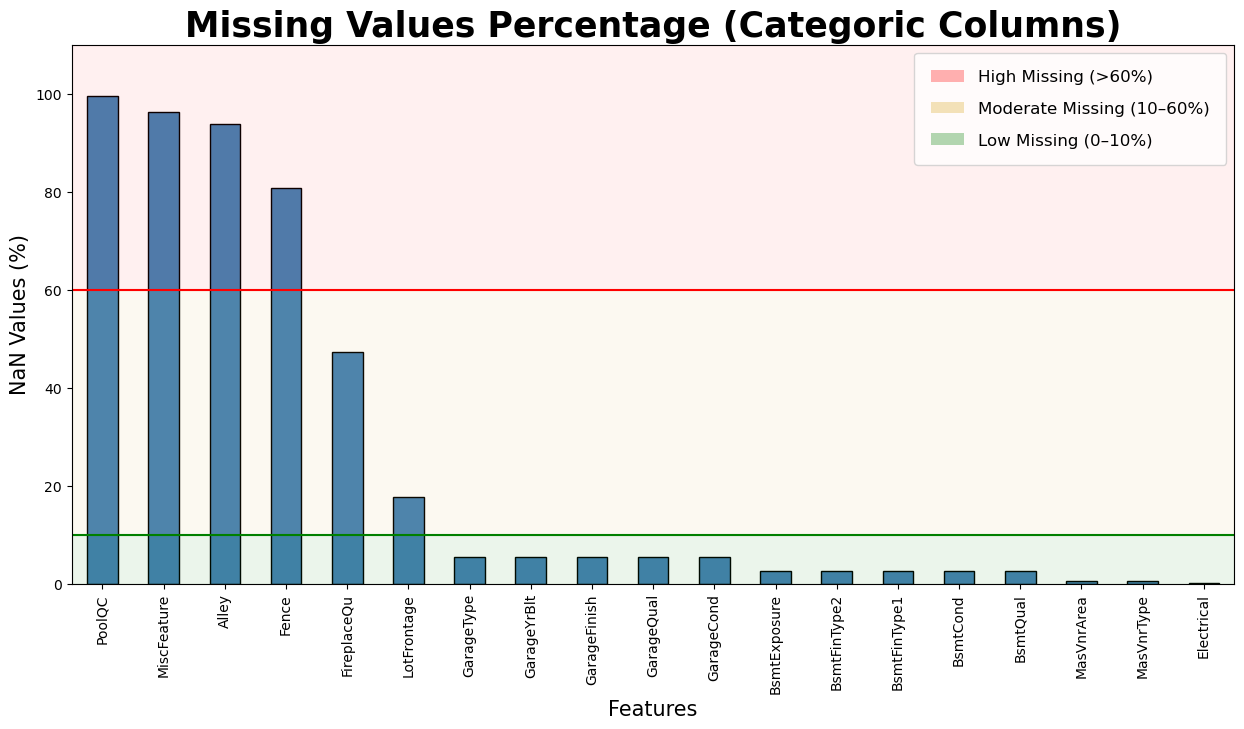

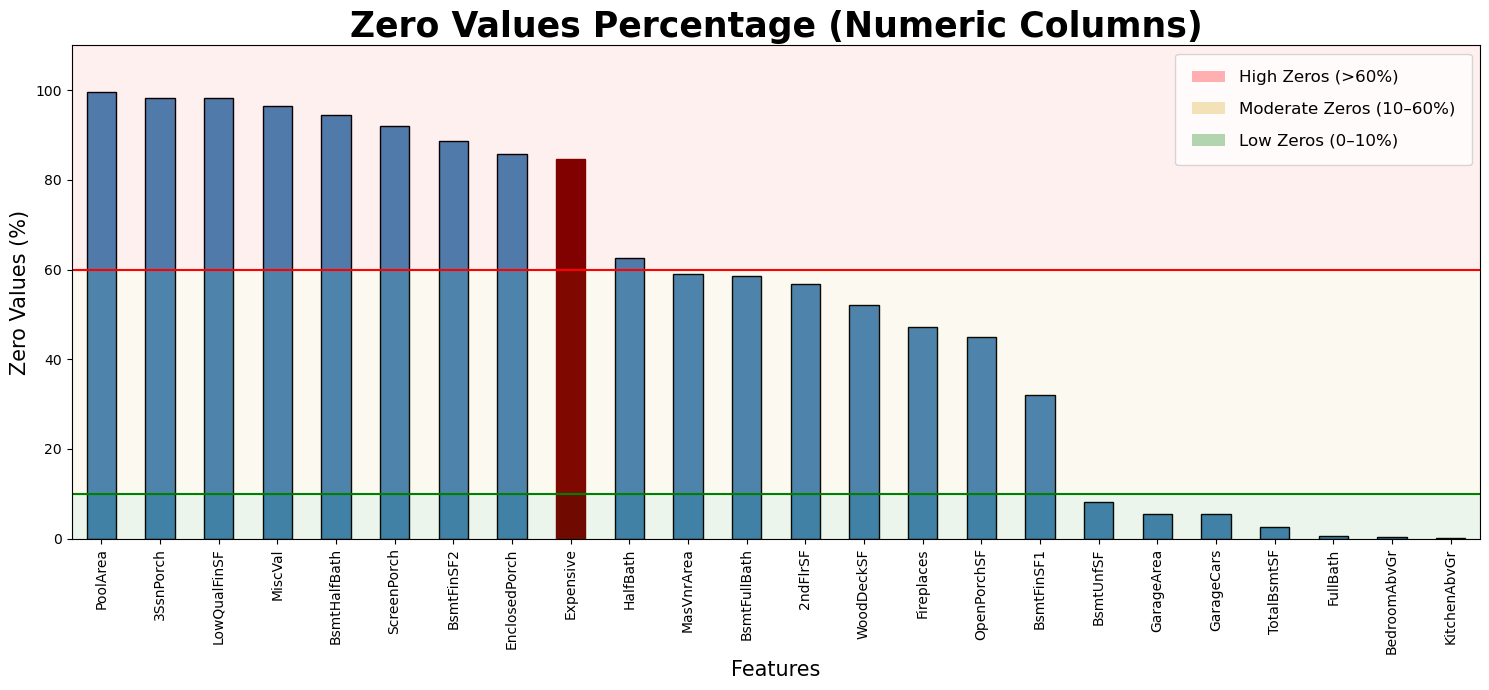

In [7]:
def missing_visual(df, color = "steelblue", edgecolor = "black", height = 7, width = 15):
    plt.figure(figsize=(width, height))
    persantage = (df.isnull().mean()) * 100
    ax = persantage[persantage > 0]\
        .sort_values(ascending=False)\
        .plot.bar(color=color, edgecolor=edgecolor, linewidth=1)

    plt.axhspan(0, 10, color='green', alpha=0.08)
    plt.axhspan(10, 60, color='goldenrod', alpha=0.06)
    ax.margins(y=0)
    ax.set_ylim(0, 110)
    plt.axhspan(60, ax.get_ylim()[1], color='red', alpha=0.06)

    plt.axhline(y = 10, color="green", linestyle = "-")
    #plt.axhline(y = 35, color="goldenrod", linestyle = "--")
    plt.axhline(y = 60, color="red", linestyle = "-")

    legend_elements = [
        Patch(facecolor='red', alpha=0.3, label='High Missing (>60%)'),
        Patch(facecolor='goldenrod', alpha=0.3, label='Moderate Missing (10–60%)'),
        Patch(facecolor='green', alpha=0.3, label='Low Missing (0–10%)')
    ]
    ax.legend(handles=legend_elements, 
              loc="upper right", 
              fontsize=12, 
              labelspacing=1, 
              frameon=True, 
              borderpad=1)

    plt.title("Missing Values Percentage (Categoric Columns)", fontsize=25, weight="bold")
    plt.xlabel("Features", fontsize=15)
    plt.ylabel("NaN Values (%)", fontsize=15)

    
    return plt.show()

def zero_visual(df, color="steelblue", edgecolor="black", height=7, width=15, threshold=0.0):
    num = df.select_dtypes(include="number")
    if num.shape[1] == 0:
        print("No numeric columns found.")
        return

    pct_zero = (num.eq(0).mean() * 100).sort_values(ascending=False)
    pct_zero = pct_zero[pct_zero > threshold]

    plt.figure(figsize=(width, height))
    ax = pct_zero.plot.bar(color=color, edgecolor=edgecolor, linewidth=1)
    ax.patches[8].set_color("#7A0000")

    plt.axhspan(0, 10, color='green', alpha=0.08)
    plt.axhspan(10, 60, color='goldenrod', alpha=0.06)
    ax.margins(y=0)
    ax.set_ylim(0, 110)
    plt.axhspan(60, ax.get_ylim()[1], color='red', alpha=0.06)

    plt.axhline(y=10, color="green", linestyle="-")
    plt.axhline(y=60, color="red", linestyle="-")

    legend_elements = [
        Patch(facecolor='red', alpha=0.3, label='High Zeros (>60%)'),
        Patch(facecolor='goldenrod', alpha=0.3, label='Moderate Zeros (10–60%)'),
        Patch(facecolor='green', alpha=0.3, label='Low Zeros (0–10%)')
    ]
    ax.legend(handles=legend_elements, loc="upper right", fontsize=12, labelspacing=1, frameon=True, borderpad=1)

    plt.title("Zero Values Percentage (Numeric Columns)", fontsize=25, weight="bold")
    plt.xlabel("Features", fontsize=15)
    plt.ylabel("Zero Values (%)", fontsize=15)
    plt.tight_layout()
    plt.show()


missing_visual(df)
zero_visual(df)


In [8]:
pd.crosstab(df["PoolQC"].isnull(), df["Expensive"], normalize="index")

Expensive,0,1
PoolQC,,
False,0.571429,0.428571
True,0.847213,0.152787


<Axes: xlabel='PoolArea', ylabel='Expensive'>

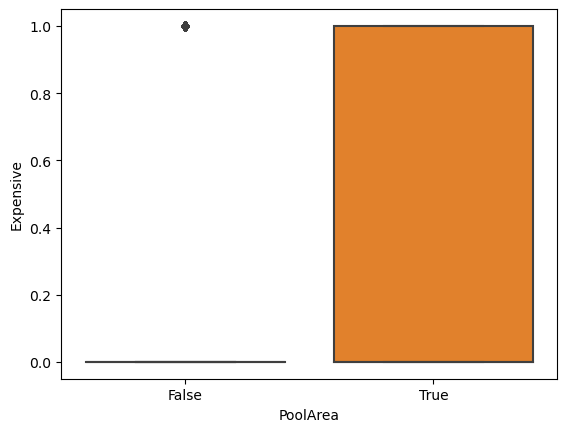

In [9]:
sns.boxplot(x=df["PoolArea"] > 0, y=df["Expensive"])

Check multicollinearity

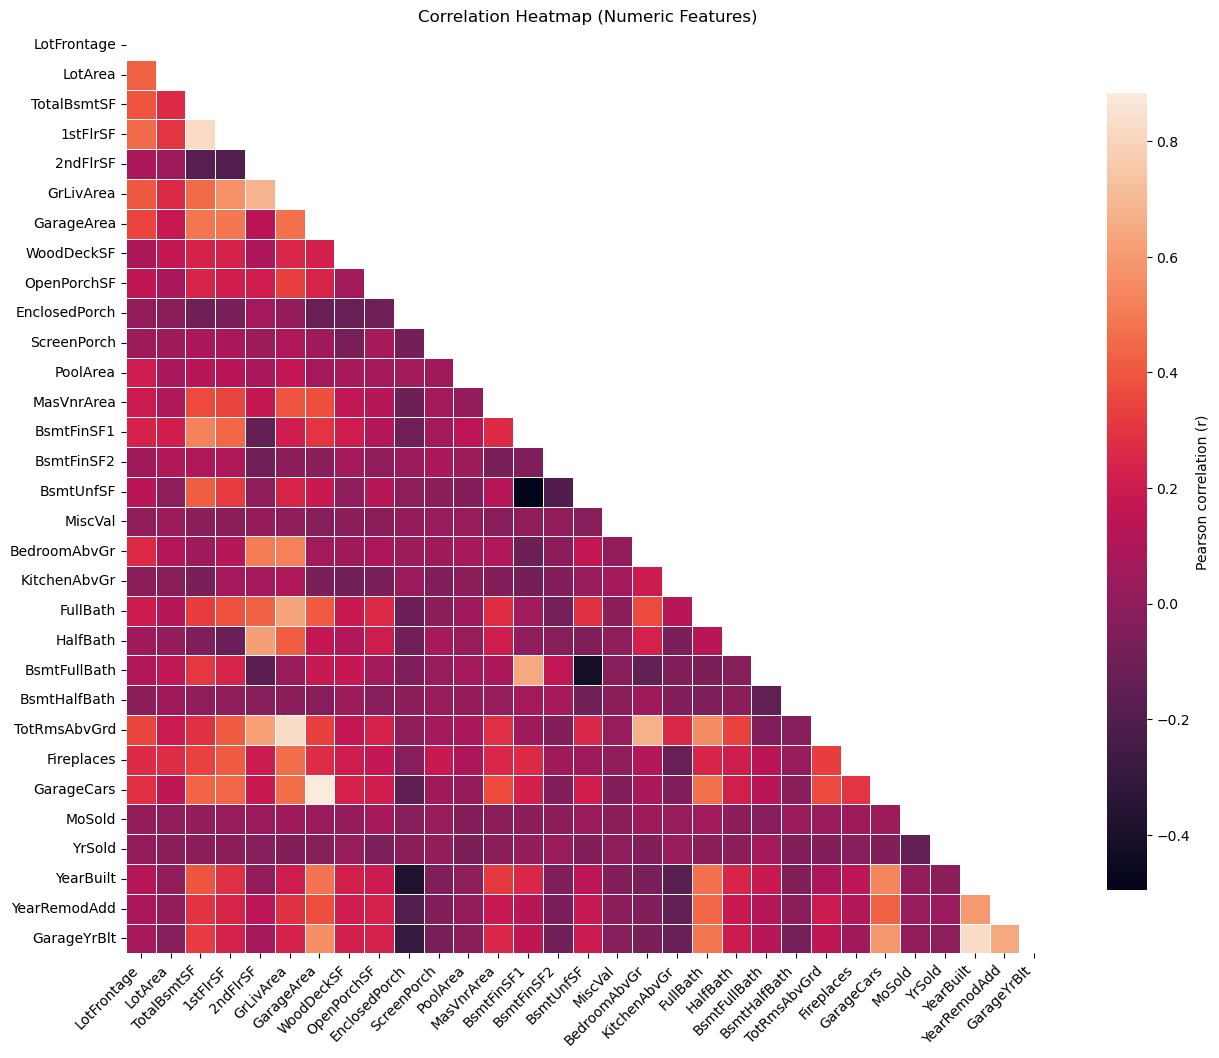

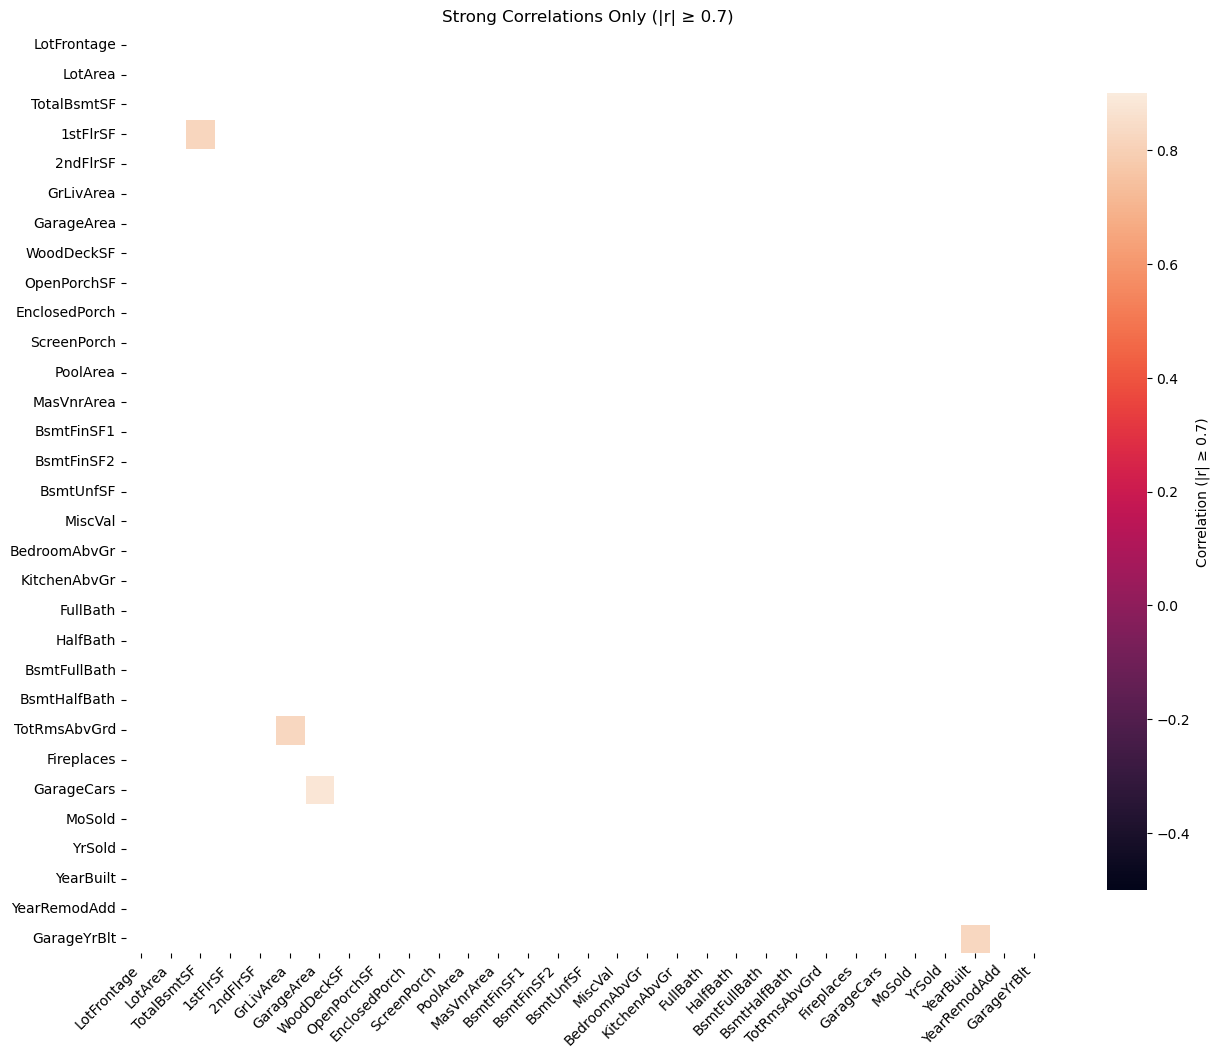

In [10]:
corr = df[numerical_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
threshold = 0.7

def pearson_correlation():
    plt.figure(figsize=(13,11))
    sns.heatmap(
        corr,
        mask=mask,
        linewidths=0.5,
        annot=False,
        square=True, 
        cbar_kws={"shrink": 0.8, "label": "Pearson correlation (r)"}
    )
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.title("Correlation Heatmap (Numeric Features)")
    plt.tight_layout()
    plt.show()

def strong_pearson_correlation():
    corr[(corr.abs() < threshold)] = np.nan
    plt.figure(figsize=(13, 11))
    sns.heatmap(
        corr,
        mask=mask,
        linewidths=0.5,
        vmin=-0.5, vmax=0.9,
        square=True,
        annot=False,
        cbar_kws={"shrink": 0.8, "label": f"Correlation (|r| ≥ {threshold})"}
    )
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.title(f"Strong Correlations Only (|r| ≥ {threshold})")
    plt.tight_layout()
    plt.show()

pearson_correlation()
strong_pearson_correlation()

The correlation heatmap (|r| ≥ 0.7) shows only a few strong correlations, 
primarily between structurally related variables such as GarageArea–GarageCars and YearBuilt–GarageYrBlt. 
These relationships are logically expected and do not indicate problematic redundancy.
Overall, no severe multicollinearity was detected, and the dataset is appropriate for Logistic Regression.
But we wil test more model types.

---

In [11]:
df.corr()["Expensive"].sort_values(ascending=False)

/var/folders/cb/nv527ffd4sn4f92077l2twqr0000gn/T/ipykernel_16238/104743523.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.corr()["Expensive"].sort_values(ascending=False)


Expensive        1.000000
OverallQual      0.595040
GrLivArea        0.525383
GarageArea       0.482838
1stFlrSF         0.465698
TotalBsmtSF      0.464896
GarageCars       0.463168
TotRmsAbvGrd     0.402204
MasVnrArea       0.389359
FullBath         0.350866
Fireplaces       0.347565
YearRemodAdd     0.338185
YearBuilt        0.331858
GarageYrBlt      0.328245
BsmtFinSF1       0.310916
LotFrontage      0.274125
OpenPorchSF      0.253176
WoodDeckSF       0.251255
2ndFlrSF         0.223250
LotArea          0.206445
BsmtFullBath     0.194914
HalfBath         0.157935
BsmtUnfSF        0.152075
ScreenPorch      0.098029
BedroomAbvGr     0.088516
MoSold           0.062868
PoolArea         0.056266
3SsnPorch        0.009570
MiscVal         -0.006254
Id              -0.024830
YrSold          -0.027927
LowQualFinSF    -0.028999
BsmtFinSF2      -0.031322
BsmtHalfBath    -0.047254
MSSubClass      -0.080163
EnclosedPorch   -0.080655
OverallCond     -0.082627
KitchenAbvGr    -0.090255
Name: Expens

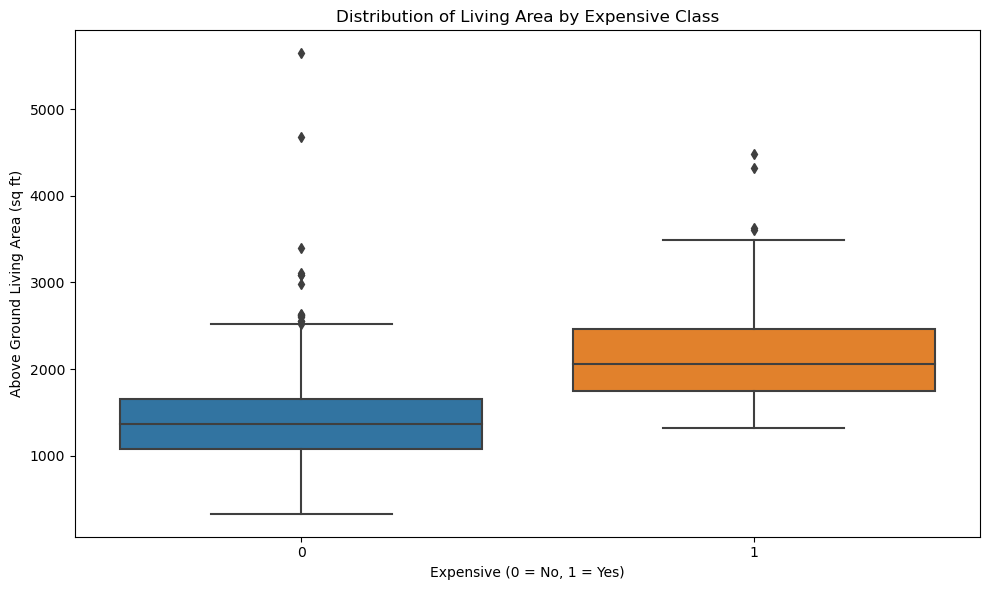

In [12]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x="Expensive", y="GrLivArea", data=df)

plt.title("Distribution of Living Area by Expensive Class")
plt.xlabel("Expensive (0 = No, 1 = Yes)")
plt.ylabel("Above Ground Living Area (sq ft)")
plt.tight_layout()
plt.show()

### Missing Values Interpritation

This graph devided into 3 regions:
1. Columns that not crossing `Green 10%` threshold NaN values can be replased with this teqniqes(median, knn, 0, or "None" depending on meaning)
2. Columns in yellow region cen be dropped but we hawe to make a research. Maybe missing values represents None or 0.
3. Those who crossed red line contain more than 60% missing values.  
    Due to the high proportion of missing data, these columns will be dropped from the analysis.

    However, not every house includes features such as **Pool**, **Alley**, or **Fence**.  
    In these cases, missing values do not represent data errors but rather the absence of those features.  
    Therefore, these variables will be replaced with `"None"` to indicate that the property does not have that amenity.

    But!

        According to housing statistics from RubyHome real estate source, 
        only about 8% of households in the United States have a swimming pool, 
        which corresponds to approximately 10.4 million residential swimming pools nationwide.
        
    This supports the decision to treat missing `Pool` values as absence rather than unknown data because only 0.48% housholders in data have `Pool`.


### Missing Values Interpretation

This graph is divided into three regions:

1. **Low Missing (0–10%) – Green Region**  
   Columns below the 10% threshold contain few missing values.  
   These can be imputed using appropriate techniques such as median imputation, KNN, `0`, or `"None"` depending on the feature meaning.

2. **Moderate Missing (10–60%) – Yellow Region**  
   Columns in this region require further research.  
   Missing values may represent meaningful absence (e.g., no garage or no fireplace) rather than true data gaps.  
   We should decide whether to impute, encode as `"None"`, or remove the feature.

3. **High Missing (>60%) – Red Region**  
   Columns above the 60% threshold contain a high proportion of missing values.  
   Due to the large amount of missing data, these features can be considered for removal. 
   Howewer not every house includes features such as **Pool**, **Alley**, or **Fence**.
   In these cases, missing values do not represent data errors but rather the absence of those amenities. 
   Therefore, these variables may be replaced with `"None"` to indicate that the property does not include that feature.
   We will test each feture.

##### Pool Feature Research

According to housing statistics from the RubyHome real estate source, only about **8% of households in the United States have a swimming pool**, 
corresponding to approximately **10.4 million residential swimming pools nationwide**.

In this dataset, only **0.48% of properties have a recorded pool**, which strongly suggests that missing `Pool` values represent the absence of a pool 
rather than unknown information.  
Therefore, we drop this feture.

In [13]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
X = df[numeric_cols].drop(columns=["Expensive"])  # remove target

In [14]:
X_const = sm.add_constant(X)
X_const.head(5)

,const,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
0,1.0,1,60,65.0,8450,7,5,2003,2003,196.0,706,0,150,856,856,854,0,1710,1,0,2,1,3,1,8,0,2003.0,2,548,0,61,0,0,0,0,0,2,2008
1,1.0,2,20,80.0,9600,6,8,1976,1976,0.0,978,0,284,1262,1262,0,0,1262,0,1,2,0,3,1,6,1,1976.0,2,460,298,0,0,0,0,0,0,5,2007
2,1.0,3,60,68.0,11250,7,5,2001,2002,162.0,486,0,434,920,920,866,0,1786,1,0,2,1,3,1,6,1,2001.0,2,608,0,42,0,0,0,0,0,9,2008
3,1.0,4,70,60.0,9550,7,5,1915,1970,0.0,216,0,540,756,961,756,0,1717,1,0,1,0,3,1,7,1,1998.0,3,642,0,35,272,0,0,0,0,2,2006
4,1.0,5,60,84.0,14260,8,5,2000,2000,350.0,655,0,490,1145,1145,1053,0,2198,1,0,2,1,4,1,9,1,2000.0,3,836,192,84,0,0,0,0,0,12,2008


In [15]:
r, p = pointbiserialr(df['Expensive'], df['OverallQual'])

print(f"Correlation: {r:.4f}")
print(f"P-value: {p:.6f}")

Correlation: 0.5950
P-value: 0.000000


In [16]:
# ---- Target / features ----
TARGET_COL = "Expensive"
assert TARGET_COL in df.columns, f"Target column {TARGET_COL!r} not found in the dataset."
assert "SalePrice" not in df.columns, "Leakage risk: SalePrice must not be included in X."

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

print("Target definition:")
print(f"Expensive = 1 if original Kaggle SalePrice >= {EXPENSIVE_THRESHOLD:,.0f} (top {1-EXPENSIVE_QUANTILE:.0%} segment).")
print("Kaggle test.csv is not included in training because it has no real SalePrice labels.")

print("\nClass distribution (counts):")
print(y.value_counts())
print("\nClass distribution (percent):")
print((y.value_counts(normalize=True) * 100).round(2))


Target definition:
Expensive = 1 if original Kaggle SalePrice >= 250,000 (top 15% segment).
Kaggle test.csv is not included in training because it has no real SalePrice labels.

Class distribution (counts):
0    1235
1     225
Name: Expensive, dtype: int64

Class distribution (percent):
0    84.59
1    15.41
Name: Expensive, dtype: float64


## Target definition and leakage control
The notebook now uses the official Kaggle `train.csv` for modelling. `Expensive` is created from the top 15% of `SalePrice`, then `SalePrice` is removed before training. The Kaggle `test.csv` has more rows but no real `SalePrice`, so it is stored separately as `kaggle_test` and should only be used after training to generate predictions.


## Train/Test Split
We keep a held-out **test set** for final evaluation only.  
We stratify to preserve the class ratio.


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (1168, 80) Test: (292, 80)


## Baseline
A baseline is mandatory. It answers: **do we beat a trivial strategy?**  
We start with a `DummyClassifier` that always predicts the most frequent class.


In [18]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix

dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
y_dummy = dummy.predict(X_test)

print("=== Dummy Baseline (most_frequent) ===")
print(classification_report(y_test, y_dummy, digits=3))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_dummy))


=== Dummy Baseline (most_frequent) ===
              precision    recall  f1-score   support

           0      0.846     1.000     0.917       247
           1      0.000     0.000     0.000        45

    accuracy                          0.846       292
   macro avg      0.423     0.500     0.458       292
weighted avg      0.716     0.846     0.775       292

Confusion matrix:
[[247   0]
 [ 45   0]]


/Users/roma/anaconda3/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/roma/anaconda3/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/roma/anaconda3/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


## Preprocessing (leakage-safe)
We automatically detect:
- **Numeric features** → median imputation (+ scaling for distance/linear models)
- **Categorical features (if any)** → most-frequent imputation + one-hot encoding

> If the dataset contains only numeric features, the categorical branch is skipped.


In [19]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_features = X.select_dtypes(include=["number"]).columns.tolist()
cat_features = X.select_dtypes(exclude=["number"]).columns.tolist()

print("Numeric features:", len(num_features), num_features)
print("Categorical features:", len(cat_features), cat_features)

def make_preprocessor_for(X_frame, scale_numeric: bool):
    numeric_features = X_frame.select_dtypes(include=["number"]).columns.tolist()
    categorical_features = X_frame.select_dtypes(exclude=["number"]).columns.tolist()

    num_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        num_steps.append(("scaler", StandardScaler()))
    num_pipe = Pipeline(steps=num_steps)

    transformers = [("num", num_pipe, numeric_features)]
    if len(categorical_features) > 0:
        cat_pipe = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ])
        transformers.append(("cat", cat_pipe, categorical_features))

    return ColumnTransformer(transformers=transformers, remainder="drop")

def make_preprocessor(scale_numeric: bool):
    return make_preprocessor_for(X, scale_numeric=scale_numeric)

# Trees do not need scaling; KNN/LogReg do.
preprocess_tree = make_preprocessor(scale_numeric=False)
preprocess_scaled = make_preprocessor(scale_numeric=True)


Numeric features: 37 ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']
Categorical features: 43 ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'G

## Evaluation strategy (metrics)
Because accuracy can hide poor minority-class performance, we use:
- **F1** for model selection (balances precision & recall)
- **ROC-AUC** (ranking quality across thresholds)
- **PR-AUC** (often more informative with class imbalance)

We also inspect confusion matrices to understand error types.


## Models and rationale
We compare complementary models:
1. **Logistic Regression** — strong, interpretable baseline
2. **Decision Tree** — captures non-linear rules
3. **KNN** — local similarity; sensitive to scaling (handled above)

We tune Tree and KNN with cross-validation. We tune `C` for Logistic Regression.


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

pipe_logreg = Pipeline(steps=[
    ("prep", preprocess_scaled),
    ("model", LogisticRegression(max_iter=3000, random_state=RANDOM_STATE))
])

pipe_logreg_balanced = Pipeline(steps=[
    ("prep", preprocess_scaled),
    ("model", LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE))
])

pipe_tree = Pipeline(steps=[
    ("prep", preprocess_tree),
    ("model", DecisionTreeClassifier(random_state=RANDOM_STATE))
])

pipe_knn = Pipeline(steps=[
    ("prep", preprocess_scaled),
    ("model", KNeighborsClassifier())
])

pipe_rf = Pipeline(steps=[
    ("prep", preprocess_tree),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

pipe_gb = Pipeline(steps=[
    ("prep", preprocess_tree),
    ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))
])


In [21]:
pipe_logreg

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Id', 'MSSubClass',
                                                   'LotFrontage', 'LotArea',
                                                   'OverallQual', 'OverallCond',
                                                   'YearBuilt', 'YearRemodAdd',
                                                   'MasVnrArea', 'BsmtFinSF1',
                                                   'BsmtFinSF2', 'BsmtUnfSF',
                                                   'TotalBsmtSF', '1stFlrSF',
                                                   '2ndFlrSF', 'LowQualFin...
                                                   'Neighborhood', 'Condition1',
                                                   'Condition2', 'BldgType',
                                                   'HouseStyle', 'RoofStyle',
                                                   'RoofMatl', 'Exterior1st',
                                                   'Exterior2nd', 'MasVnrType',
                                                   'ExterQual', 'ExterCond',
                                                   'Foundation', 'BsmtQual',
                                                   'BsmtCond', 'BsmtExposure',
                                                   'BsmtFinType1',
                                                   'BsmtFinType2', 'Heating',
                                                   'HeatingQC', 'CentralAir',
                                                   'Electrical', ...])])),
                ('model', LogisticRegression(max_iter=3000, random_state=42))])

## Cross-validation + hyperparameter tuning
We use stratified CV to preserve class balance in each fold.


In [22]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_tree = {
    "model__max_depth": [2, 3, 5, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 5, 10],
}

grid_knn = {
    "model__n_neighbors": [3, 5, 7, 11, 15],
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2],
}

grid_logreg = {"model__C": [0.1, 1, 10]}
grid_logreg_balanced = {"model__C": [0.1, 1, 10]}

grid_rf = {
    "model__n_estimators": [200],
    "model__max_depth": [None, 8, 16],
    "model__min_samples_leaf": [1, 3, 5],
    "model__class_weight": [None, "balanced"],
}

grid_gb = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3],
    "model__min_samples_leaf": [1, 5],
}

searches = {
    "Decision Tree": GridSearchCV(pipe_tree, grid_tree, scoring="f1", cv=cv, n_jobs=-1),
    "KNN": GridSearchCV(pipe_knn, grid_knn, scoring="f1", cv=cv, n_jobs=-1),
    "LogReg": GridSearchCV(pipe_logreg, grid_logreg, scoring="f1", cv=cv, n_jobs=-1),
    "LogReg balanced": GridSearchCV(pipe_logreg_balanced, grid_logreg_balanced, scoring="f1", cv=cv, n_jobs=-1),
    "Random Forest": GridSearchCV(pipe_rf, grid_rf, scoring="f1", cv=cv, n_jobs=-1),
    "Gradient Boosting": GridSearchCV(pipe_gb, grid_gb, scoring="f1", cv=cv, n_jobs=-1),
}

for name, search in searches.items():
    search.fit(X_train, y_train)
    print(f"\nBest {name} params:", search.best_params_)
    print(f"Best {name} CV F1 :", round(search.best_score_, 3))

best_tree = searches["Decision Tree"].best_estimator_
best_knn = searches["KNN"].best_estimator_
best_logreg = searches["LogReg"].best_estimator_
best_logreg_balanced = searches["LogReg balanced"].best_estimator_
best_rf = searches["Random Forest"].best_estimator_
best_gb = searches["Gradient Boosting"].best_estimator_



Best Decision Tree params: {'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5}
Best Decision Tree CV F1 : 0.772

Best KNN params: {'model__n_neighbors': 5, 'model__p': 2, 'model__weights': 'uniform'}
Best KNN CV F1 : 0.739

Best LogReg params: {'model__C': 0.1}
Best LogReg CV F1 : 0.805

Best LogReg balanced params: {'model__C': 0.1}
Best LogReg balanced CV F1 : 0.816

Best Random Forest params: {'model__class_weight': 'balanced', 'model__max_depth': 8, 'model__min_samples_leaf': 5, 'model__n_estimators': 200}
Best Random Forest CV F1 : 0.83

Best Gradient Boosting params: {'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__min_samples_leaf': 5, 'model__n_estimators': 200}
Best Gradient Boosting CV F1 : 0.835


## Test set evaluation
We now evaluate the best estimators on the held-out test set.


In [23]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, accuracy_score
)

eval_rows = []

def evaluate(model, name, X_eval=X_test, y_eval=y_test, threshold=0.5, store=True):
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_eval)[:, 1]
        y_pred = (y_proba >= threshold).astype(int)
        roc = roc_auc_score(y_eval, y_proba)
        pr = average_precision_score(y_eval, y_proba)
    else:
        y_pred = model.predict(X_eval)
        roc = np.nan
        pr = np.nan

    cm = confusion_matrix(y_eval, y_pred)
    false_negatives = cm[1, 0]
    false_positives = cm[0, 1]

    print(f"\n=== {name} ===")
    print(classification_report(y_eval, y_pred, digits=3, zero_division=0))
    print("Confusion matrix:")
    print(cm)
    print(f"ROC-AUC: {roc:.3f}")
    print(f"PR-AUC : {pr:.3f}")
    print(f"False negatives: {false_negatives}")

    row = {
        "model": name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_eval, y_pred),
        "precision_expensive": precision_score(y_eval, y_pred, zero_division=0),
        "recall_expensive": recall_score(y_eval, y_pred, zero_division=0),
        "f1_expensive": f1_score(y_eval, y_pred, zero_division=0),
        "roc_auc": roc,
        "pr_auc": pr,
        "false_negatives": false_negatives,
        "false_positives": false_positives,
        "total_mistakes": int((y_eval != y_pred).sum()),
    }
    if store:
        eval_rows.append(row)
    return row

fitted_models = {
    "Dummy Baseline": dummy,
    "LogReg tuned": best_logreg,
    "LogReg balanced": best_logreg_balanced,
    "Decision Tree tuned": best_tree,
    "KNN tuned": best_knn,
    "Random Forest tuned": best_rf,
    "Gradient Boosting tuned": best_gb,
}

for name, model in fitted_models.items():
    evaluate(model, name)

eval_df = pd.DataFrame(eval_rows).sort_values(
    by=["f1_expensive", "recall_expensive", "false_negatives"],
    ascending=[False, False, True]
)
display(eval_df.round(3))



=== Dummy Baseline ===
              precision    recall  f1-score   support

           0      0.846     1.000     0.917       247
           1      0.000     0.000     0.000        45

    accuracy                          0.846       292
   macro avg      0.423     0.500     0.458       292
weighted avg      0.716     0.846     0.775       292

Confusion matrix:
[[247   0]
 [ 45   0]]
ROC-AUC: 0.500
PR-AUC : 0.154
False negatives: 45

=== LogReg tuned ===
              precision    recall  f1-score   support

           0      0.960     0.972     0.966       247
           1      0.833     0.778     0.805        45

    accuracy                          0.942       292
   macro avg      0.897     0.875     0.885       292
weighted avg      0.940     0.942     0.941       292

Confusion matrix:
[[240   7]
 [ 10  35]]
ROC-AUC: 0.987
PR-AUC : 0.935
False negatives: 10

=== LogReg balanced ===
              precision    recall  f1-score   support

           0      0.991     0.939     

,model,threshold,accuracy,precision_expensive,recall_expensive,f1_expensive,roc_auc,pr_auc,false_negatives,false_positives,total_mistakes
6,Gradient Boosting tuned,0.5,0.952,0.844,0.844,0.844,0.989,0.952,7,7,14
2,LogReg balanced,0.5,0.942,0.741,0.956,0.835,0.986,0.933,2,15,17
5,Random Forest tuned,0.5,0.938,0.745,0.911,0.820,0.984,0.914,4,14,18
1,LogReg tuned,0.5,0.942,0.833,0.778,0.805,0.987,0.935,10,7,17
4,KNN tuned,0.5,0.945,0.914,0.711,0.800,0.956,0.882,13,3,16
3,Decision Tree tuned,0.5,0.928,0.740,0.822,0.779,0.862,0.654,8,13,21
0,Dummy Baseline,0.5,0.846,0.000,0.000,0.000,0.500,0.154,45,0,45


## Model comparison (interpretation)
After reviewing test performance:
- **LogReg** indicates how much signal is available in roughly linear form.
- **Tree** often wins when there are non-linear interactions (e.g., “size + amenity” rules).
- **KNN** can perform well but is less interpretable and more sensitive to noise.

In professional settings, we typically prefer the model that offers the best trade-off between:
- performance on the expensive class (recall/F1),
- stability,
- interpretability.


## Threshold tuning (methodologically clean)
Default threshold is 0.5. If false negatives are costly, we may prefer a different threshold.

To avoid optimistic bias, we **choose the threshold on a validation split** from the training data,
then report its performance on the held-out test set.


In [24]:
from sklearn.metrics import precision_recall_curve
from sklearn.base import clone

# Validation split from training data. Clone models so threshold tuning does not overwrite the fitted final estimators.
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.25,
    stratify=y_train,
    random_state=RANDOM_STATE
)

def choose_threshold_by_f1(model, X_val, y_val):
    proba = model.predict_proba(X_val)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_val, proba)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-12)
    if len(thresholds) == 0:
        return 0.5, float(f1.max())
    best_idx = np.argmax(f1[:-1])
    return float(thresholds[best_idx]), float(f1[best_idx])

threshold_rows = []
for name, fitted_model in fitted_models.items():
    if name == "Dummy Baseline" or not hasattr(fitted_model, "predict_proba"):
        continue
    model_for_threshold = clone(fitted_model)
    model_for_threshold.fit(X_tr, y_tr)
    thr, best_val_f1 = choose_threshold_by_f1(model_for_threshold, X_val, y_val)
    row = evaluate(fitted_model, f"{name} @ tuned threshold", threshold=thr, store=False)
    row["validation_f1"] = best_val_f1
    threshold_rows.append(row)

threshold_df = pd.DataFrame(threshold_rows).sort_values(
    by=["f1_expensive", "recall_expensive", "false_negatives"],
    ascending=[False, False, True]
)
display(threshold_df.round(3))



=== LogReg tuned @ tuned threshold ===
              precision    recall  f1-score   support

           0      0.967     0.955     0.961       247
           1      0.771     0.822     0.796        45

    accuracy                          0.935       292
   macro avg      0.869     0.889     0.879       292
weighted avg      0.937     0.935     0.936       292

Confusion matrix:
[[236  11]
 [  8  37]]
ROC-AUC: 0.987
PR-AUC : 0.935
False negatives: 8

=== LogReg balanced @ tuned threshold ===
              precision    recall  f1-score   support

           0      0.979     0.947     0.963       247
           1      0.755     0.889     0.816        45

    accuracy                          0.938       292
   macro avg      0.867     0.918     0.890       292
weighted avg      0.945     0.938     0.940       292

Confusion matrix:
[[234  13]
 [  5  40]]
ROC-AUC: 0.986
PR-AUC : 0.933
False negatives: 5

=== Decision Tree tuned @ tuned threshold ===
              precision    recall  f

,model,threshold,accuracy,precision_expensive,recall_expensive,f1_expensive,roc_auc,pr_auc,false_negatives,false_positives,total_mistakes,validation_f1
3,KNN tuned @ tuned threshold,0.400,0.966,0.907,0.867,0.886,0.956,0.882,6,4,10,0.780
5,Gradient Boosting tuned @ tuned threshold,0.641,0.949,0.841,0.822,0.831,0.989,0.952,8,7,15,0.864
1,LogReg balanced @ tuned threshold,0.594,0.938,0.755,0.889,0.816,0.986,0.933,5,13,18,0.872
4,Random Forest tuned @ tuned threshold,0.523,0.932,0.736,0.867,0.796,0.984,0.914,6,14,20,0.876
0,LogReg tuned @ tuned threshold,0.347,0.935,0.771,0.822,0.796,0.987,0.935,8,11,19,0.841
2,Decision Tree tuned @ tuned threshold,0.250,0.928,0.740,0.822,0.779,0.862,0.654,8,13,21,0.796


## Error analysis
We inspect misclassifications to understand *where* the model fails.  


In [25]:
def error_analysis(model, model_name, threshold=0.5):
    errors = X_test.copy()
    errors["y_true"] = y_test.values
    if hasattr(model, "predict_proba"):
        errors["predicted_probability"] = model.predict_proba(X_test)[:, 1]
        errors["y_pred"] = (errors["predicted_probability"] >= threshold).astype(int)
    else:
        errors["predicted_probability"] = np.nan
        errors["y_pred"] = model.predict(X_test)

    mistakes = errors[errors["y_true"] != errors["y_pred"]]
    false_negatives = errors[(errors["y_true"] == 1) & (errors["y_pred"] == 0)]
    false_positives = errors[(errors["y_true"] == 0) & (errors["y_pred"] == 1)]

    print(f"\n=== {model_name} ===")
    print(f"Total test rows: {len(errors)}")
    print(f"Mistakes: {len(mistakes)}")
    print(f"False negatives (costly): {len(false_negatives)}")
    print(f"False positives: {len(false_positives)}")

    display(mistakes[["y_true", "y_pred", "predicted_probability"]].head(10))

top_default_models = eval_df.head(3)["model"].tolist()
for model_name in top_default_models:
    error_analysis(fitted_models[model_name], model_name)



=== Gradient Boosting tuned ===
Total test rows: 292
Mistakes: 14
False negatives (costly): 7
False positives: 7


,y_true,y_pred,predicted_probability
541,0,1,0.808896
249,1,0,0.247922
1342,0,1,0.719665
158,1,0,0.176824
290,0,1,0.739623
673,1,0,0.127152
747,1,0,0.470304
792,1,0,0.457119
324,0,1,0.657921
1348,0,1,0.663739



=== LogReg balanced ===
Total test rows: 292
Mistakes: 17
False negatives (costly): 2
False positives: 15


,y_true,y_pred,predicted_probability
541,0,1,0.832444
1196,0,1,0.735660
1342,0,1,0.612440
244,0,1,0.580148
1375,0,1,0.772541
1369,0,1,0.656113
290,0,1,0.790991
747,1,0,0.481676
324,0,1,0.927067
1348,0,1,0.594339



=== Random Forest tuned ===
Total test rows: 292
Mistakes: 18
False negatives (costly): 4
False positives: 14


,y_true,y_pred,predicted_probability
541,0,1,0.654562
1196,0,1,0.533458
249,1,0,0.404472
1342,0,1,0.686991
158,1,0,0.499902
1375,0,1,0.753936
1369,0,1,0.626037
290,0,1,0.710956
673,1,0,0.367329
1133,0,1,0.539350


## Interpretability: permutation importance
Permutation importance estimates how much each feature contributes to model performance.
It is model-agnostic and works well with pipelines.


## Low-signal feature pruning experiment
Some variables are identifiers or almost always zero. This test removes them and checks whether the simpler feature set improves performance. The reduced model is only preferred if it improves expensive-class F1/recall or reduces false negatives.


In [26]:
candidate_drop_cols = ["Id", "PoolArea", "MiscVal", "3SsnPorch", "LowQualFinSF"]
drop_cols = [col for col in candidate_drop_cols if col in X.columns]

X_train_reduced = X_train.drop(columns=drop_cols)
X_test_reduced = X_test.drop(columns=drop_cols)

reduced_preprocess = make_preprocessor_for(X_train_reduced, scale_numeric=True)
reduced_logreg_balanced = Pipeline(steps=[
    ("prep", reduced_preprocess),
    ("model", LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE))
])

reduced_search = GridSearchCV(
    reduced_logreg_balanced,
    param_grid={"model__C": [0.1, 1, 10]},
    scoring="f1",
    cv=cv,
    n_jobs=-1,
)
reduced_search.fit(X_train_reduced, y_train)

print("Dropped columns:", drop_cols)
print("Best reduced-model params:", reduced_search.best_params_)
print("Best reduced-model CV F1:", round(reduced_search.best_score_, 3))

reduced_row = evaluate(
    reduced_search.best_estimator_,
    "LogReg balanced reduced features",
    X_eval=X_test_reduced,
    y_eval=y_test,
    store=False,
)
display(pd.DataFrame([reduced_row]).round(3))


Dropped columns: ['Id', 'PoolArea', 'MiscVal', '3SsnPorch', 'LowQualFinSF']
Best reduced-model params: {'model__C': 0.1}
Best reduced-model CV F1: 0.833

=== LogReg balanced reduced features ===
              precision    recall  f1-score   support

           0      0.991     0.935     0.963       247
           1      0.729     0.956     0.827        45

    accuracy                          0.938       292
   macro avg      0.860     0.945     0.895       292
weighted avg      0.951     0.938     0.942       292

Confusion matrix:
[[231  16]
 [  2  43]]
ROC-AUC: 0.986
PR-AUC : 0.931
False negatives: 2


,model,threshold,accuracy,precision_expensive,recall_expensive,f1_expensive,roc_auc,pr_auc,false_negatives,false_positives,total_mistakes
0,LogReg balanced reduced features,0.5,0.938,0.729,0.956,0.827,0.986,0.931,2,16,18


In [27]:
from sklearn.inspection import permutation_importance

final_model_name = eval_df.iloc[0]["model"]
final_model = fitted_models[final_model_name]
print("Final default-threshold model selected for interpretation:", final_model_name)

def get_permutation_importance(model, model_name, X_test, y_test):
    perm = permutation_importance(
        model,
        X_test, y_test,
        n_repeats=30,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    importances = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)
    print(f"\n === {model_name} ===")
    display(importances.head(30))
    return importances

final_importances = get_permutation_importance(final_model, final_model_name, X_test, y_test)


Final default-threshold model selected for interpretation: Gradient Boosting tuned

 === Gradient Boosting tuned ===


OverallQual     0.040411
GrLivArea       0.019064
BsmtFinSF1      0.003539
2ndFlrSF        0.003425
TotalBsmtSF     0.002055
Neighborhood    0.001712
KitchenQual     0.001712
YearRemodAdd    0.000571
Exterior1st     0.000571
TotRmsAbvGrd    0.000342
BsmtQual        0.000342
RoofMatl        0.000114
FullBath        0.000000
Functional      0.000000
HalfBath        0.000000
BedroomAbvGr    0.000000
KitchenAbvGr    0.000000
BsmtHalfBath    0.000000
BsmtFullBath    0.000000
LowQualFinSF    0.000000
Electrical      0.000000
Id              0.000000
MSSubClass      0.000000
FireplaceQu     0.000000
YrSold          0.000000
MoSold          0.000000
MiscVal         0.000000
MiscFeature     0.000000
Fence           0.000000
PoolQC          0.000000
dtype: float64

## Summary & Conclusion

### Project Summary
This 2.0 notebook improves the housing classification workflow by addressing the main weaknesses from the first version:
- the expensive-house target is explicitly defined when `SalePrice` is available,
- `SalePrice` is removed before modelling to prevent leakage,
- imbalance is handled with a balanced Logistic Regression model,
- stronger ensemble models are added: Random Forest and Gradient Boosting,
- model selection uses expensive-class F1, recall, PR-AUC, and false negatives rather than accuracy alone,
- threshold tuning is tested separately on a validation split,
- low-signal feature removal is tested as an experiment instead of assumed.

### Model Selection Logic
The final model should be selected from the comparison table using this priority order:
1. high F1-score for the expensive class,
2. high recall for the expensive class,
3. fewer false negatives,
4. strong PR-AUC,
5. reasonable interpretability and stability.

### Limitations
- The binary target simplifies a continuous price spectrum. A regression model using real prices could capture more detail.
- The dataset is compact and may not include important market, location, or time-based features.
- Threshold tuning improves decision behaviour, but the chosen threshold should match the real cost of false negatives and false positives.

### Next Steps
- Calibrate predicted probabilities with `CalibratedClassifierCV`.
- Compare the classification approach with a regression model predicting `SalePrice`.
- Add domain-specific features, especially neighbourhood and quality interactions.
- Use repeated cross-validation for a more stable final model estimate.

### Final Note
This version makes the project stronger because it treats the housing task as a decision problem, not just a leaderboard-style accuracy problem. The selected model should be the one that best balances expensive-house recall, false-negative cost, and generalisation performance.
